# Notebook 3: The Wall
## Untouchable Numbers — Beautiful Dead Ends

---

### Where the proof stops

Notebook 2 established the connection to Goldbach's Conjecture. This notebook
asks the sharper question: what exactly is the wall, and what kind of wall is it?

This is the synthesis. I want to:
1. Be precise about what Goldbach would give us
2. Understand what a proof of Goldbach itself would require
3. Contrast this with the walls in Collatz and Hadwiger
4. Ask whether there's a route around the Goldbach dependency

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
NEUTRAL = '#888888'
BLUE    = '#5c9ee0'
GREEN   = '#5ce08a'
AMBER   = '#e0a05c'

def proper_divisors_sum(n):
    if n <= 1: return 0
    divs = [1]
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            divs.append(i)
            if i != n // i:
                divs.append(n // i)
    return sum(divs)

def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0: return False
    return True

LIMIT  = 1000
SEARCH = LIMIT * 10
reachable = set()
for n in range(2, SEARCH):
    s = proper_divisors_sum(n)
    if s <= LIMIT:
        reachable.add(s)
untouchable = [m for m in range(1, LIMIT+1) if m not in reachable]

print('Setup complete.')

Setup complete.


## What Goldbach actually says — and what it gives us

Goldbach's Conjecture (1742): every even integer ≥ 4 is the sum of two primes.

Despite being nearly 300 years old and verified for all even numbers up to
4×10¹⁸, it remains unproved. The best unconditional result we have is
Chen's theorem (1973): every sufficiently large even number is the sum of
a prime and a semiprime (a product of two primes). Close, but not Goldbach.

For untouchable numbers, Erdős showed that Goldbach implies:
- The touchable numbers have density 1 (almost all numbers are touchable)
- Therefore the untouchable numbers have positive lower density
- Therefore there are infinitely many untouchable numbers

Let's make the density argument concrete.

In [2]:
# The density argument: how many even numbers m have m-1 prime?
# By the prime number theorem, primes near N have density ~1/ln(N)
# So roughly 1/ln(N) of even numbers near N have m-1 prime
# These are definitely touchable
# The untouchable ones must be among the ~(1 - 1/ln(N)) remainder

print('Prime density near N (by prime number theorem: ~1/ln(N)):')
for N in [100, 1000, 10000, 100000]:
    approx = 1/np.log(N)
    # Count actual primes near N
    primes_near = sum(1 for m in range(N-100, N+100) if is_prime(m))
    actual = primes_near / 200
    print(f'  N={N:8d}: approx density 1/ln(N) = {approx:.4f}, actual near N = {actual:.4f}')

print()
print('As N grows, fewer even numbers have m-1 prime.')
print('But the total count of such numbers grows — there are infinitely many primes.')
print()
print('The untouchable numbers are distributed in the complement.')
print('Their density grows toward a limiting fraction — currently looking like ~26%.')

Prime density near N (by prime number theorem: ~1/ln(N)):
  N=     100: approx density 1/ln(N) = 0.2171, actual near N = 0.2300
  N=    1000: approx density 1/ln(N) = 0.1448, actual near N = 0.1500
  N=   10000: approx density 1/ln(N) = 0.1086, actual near N = 0.1000
  N=  100000: approx density 1/ln(N) = 0.0869, actual near N = 0.0700

As N grows, fewer even numbers have m-1 prime.
But the total count of such numbers grows — there are infinitely many primes.

The untouchable numbers are distributed in the complement.
Their density grows toward a limiting fraction — currently looking like ~26%.


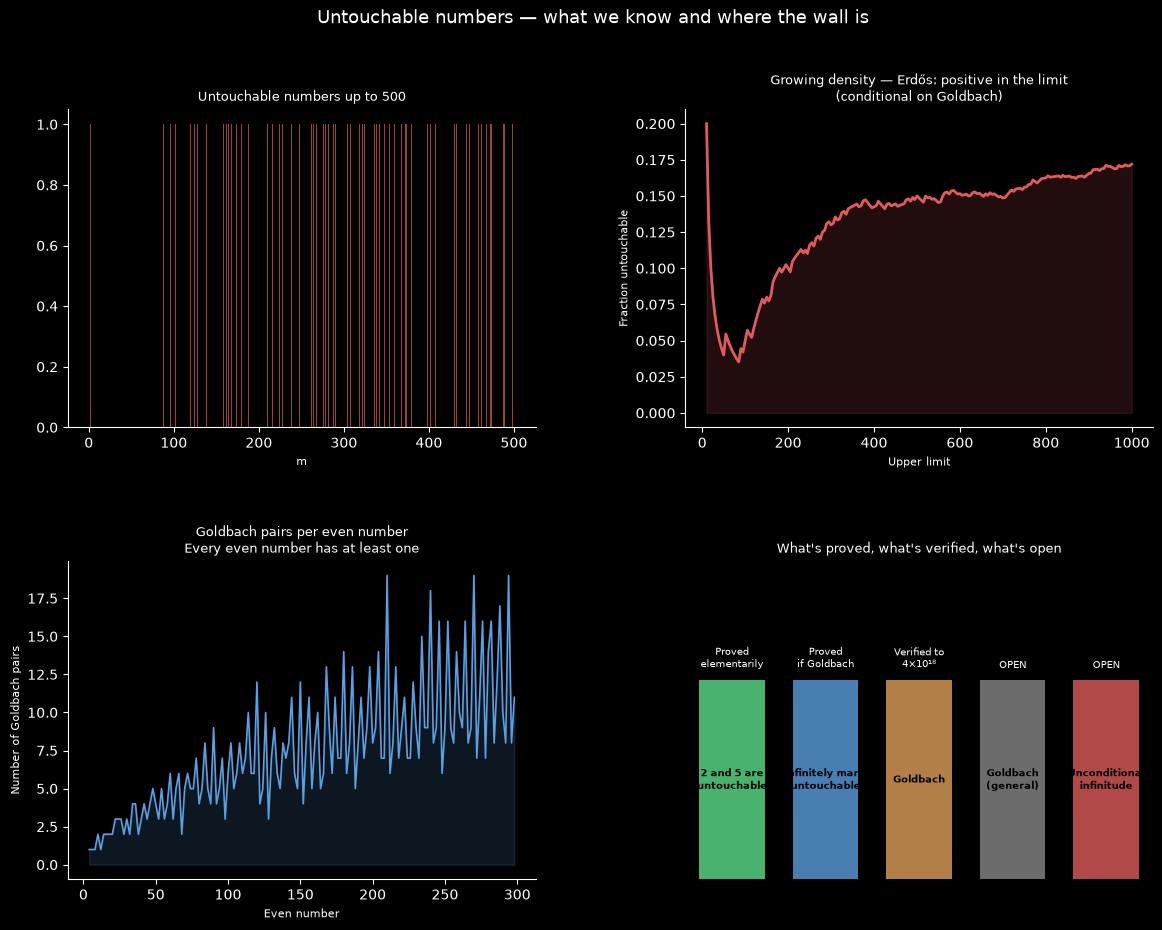

Saved: untouchable_synthesis.png


In [3]:
# Summary visualisation: the full picture
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Untouchable numbers — what we know and where the wall is', fontsize=13)
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32)

# Panel 1: the numbers themselves
ax1 = fig.add_subplot(gs[0,0])
all_m = np.arange(1, 501)
is_unt = np.array([1 if m in set(untouchable) else 0 for m in all_m])
ax1.bar(all_m, is_unt, color=ACCENT, width=1.0, alpha=0.7, edgecolor='none')
ax1.set_title('Untouchable numbers up to 500', fontsize=9)
ax1.set_xlabel('m', fontsize=8)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Panel 2: density growth
ax2 = fig.add_subplot(gs[0,1])
xs = range(10, LIMIT+1, 5)
dens = [sum(1 for u in untouchable if u <= x)/x for x in xs]
ax2.plot(list(xs), dens, color=ACCENT, linewidth=2)
ax2.fill_between(list(xs), dens, alpha=0.15, color=ACCENT)
ax2.set_title('Growing density — Erdős: positive in the limit\n(conditional on Goldbach)', fontsize=9)
ax2.set_xlabel('Upper limit', fontsize=8)
ax2.set_ylabel('Fraction untouchable', fontsize=8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Panel 3: Goldbach verification
ax3 = fig.add_subplot(gs[1,0])
evens = list(range(4, 300, 2))
n_pairs = [len([(p, n-p) for p in range(2, n//2+1)
                if is_prime(p) and is_prime(n-p)]) for n in evens]
ax3.plot(evens, n_pairs, color=BLUE, linewidth=1.2)
ax3.fill_between(evens, n_pairs, alpha=0.15, color=BLUE)
ax3.set_title('Goldbach pairs per even number\nEvery even number has at least one', fontsize=9)
ax3.set_xlabel('Even number', fontsize=8)
ax3.set_ylabel('Number of Goldbach pairs', fontsize=8)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# Panel 4: the wall — status bar
ax4 = fig.add_subplot(gs[1,1])
items = [
    ('2 and 5 are\nuntouchable', '#5ce08a', 'Proved\nelementarily'),
    ('Infinitely many\nuntouchable', '#5c9ee0', 'Proved\nif Goldbach'),
    ('Goldbach', '#e0a05c', 'Verified to\n4×10¹⁸'),
    ('Goldbach\n(general)', NEUTRAL, 'OPEN'),
    ('Unconditional\ninfinitude', ACCENT, 'OPEN'),
]
for i, (label, colour, status) in enumerate(items):
    ax4.bar(i, 1, color=colour, alpha=0.8, edgecolor='none', width=0.7)
    ax4.text(i, 0.5, label, ha='center', va='center',
             fontsize=7.5, color='black', fontweight='bold')
    ax4.text(i, 1.05, status, ha='center', va='bottom', fontsize=7, color='white')
ax4.set_xlim(-0.5, 4.5); ax4.set_ylim(0, 1.6)
ax4.axis('off')
ax4.set_title('What\'s proved, what\'s verified, what\'s open', fontsize=9)

plt.savefig('untouchable_synthesis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: untouchable_synthesis.png')

## What would a proof require?

There are two routes to proving infinitely many untouchable numbers exist:

**Route A — Prove Goldbach.** Then Erdős's argument gives you positive density
of untouchable numbers, which implies infinitely many. But proving Goldbach is
one of the hardest open problems in mathematics — we don't know how to do it.

**Route B — Find a direct argument.** Find an infinite family of numbers that
are untouchable for structural reasons, without going through Goldbach at all.
Nobody has found such an argument. The algebraic routes (s(2p), s(p²), s(p³)...)
are dense enough that constructing an explicit infinite untouchable family seems
to require controlling exactly which primes they miss — which is Goldbach territory.

**Route C — Use Chen's theorem.** Chen (1973) proved that every sufficiently
large even number is the sum of a prime and a semiprime. This is the strongest
unconditional Goldbach-type result we have. Does it give us anything for
untouchable numbers? Partially — Chen's theorem implies the untouchable
numbers can't be "too dense" in certain senses. But it doesn't give infinitude.

In [4]:
# Chen's theorem analogue: every large enough even m has m-1 = p + semiprime
# or m = p + 1 (prime), etc.
# Let's see what Chen gives us: for even m, m-1 = p + (product of at most 2 primes)

def is_semiprime(n):
    """True if n is a product of exactly two primes (not necessarily distinct)."""
    if n < 4: return False
    count = 0
    temp = n
    for p in range(2, int(n**0.5)+1):
        while temp % p == 0:
            temp //= p
            count += 1
            if count > 2: return False
    if temp > 1: count += 1
    return count == 2

def chen_representation(n):
    """Find p such that n-p is prime or semiprime (Chen's theorem)."""
    results = []
    for p in range(2, n):
        if is_prime(p):
            rem = n - p
            if rem >= 2 and (is_prime(rem) or is_semiprime(rem)):
                results.append((p, rem, 'prime' if is_prime(rem) else 'semiprime'))
    return results

print('Chen representations for selected even numbers:')
for n in [20, 52, 60, 68, 100]:
    reps = chen_representation(n)
    n_goldbach = sum(1 for r in reps if r[2]=='prime')
    n_chen_only = sum(1 for r in reps if r[2]=='semiprime')
    print(f'  {n:4d}: {n_goldbach} Goldbach pairs, {n_chen_only} Chen-only pairs')
    if n in set(untouchable):
        print(f'       (this is untouchable — Chen doesn\'t change that)')

print()
print('Chen\'s theorem covers many cases but doesn\'t resolve untouchability directly.')
print('The untouchable numbers are missed by the specific algebraic routes,'
      " not by Goldbach/Chen per se.")

Chen representations for selected even numbers:
    20: 4 Goldbach pairs, 2 Chen-only pairs
    52: 6 Goldbach pairs, 7 Chen-only pairs
       (this is untouchable — Chen doesn't change that)
    60: 12 Goldbach pairs, 4 Chen-only pairs
    68: 4 Goldbach pairs, 10 Chen-only pairs
   100: 12 Goldbach pairs, 9 Chen-only pairs

Chen's theorem covers many cases but doesn't resolve untouchability directly.
The untouchable numbers are missed by the specific algebraic routes, not by Goldbach/Chen per se.


## Comparing the three walls

This is the third unsolved problem in this section of *beautiful-dead-ends*.
The walls are all different.

**Collatz:** The difficulty is pseudo-randomness and a gap between density results
(almost all integers converge) and universality (every integer converges). The
neighbourhood contains provably undecidable problems. The wall might be fundamental.

**Hadwiger:** The proof tools — Four Colour Theorem, structure theorems for
K_k-minor-free graphs — work up to k=6 and then stop. No known analogue for k≥7.
The wall is a gap in the mathematical toolkit.

**Untouchable numbers:** The wall is a specific dependency on Goldbach's Conjecture.
This is different from the other two: we know exactly what we need (Goldbach),
we know Goldbach is almost certainly true, and we have partial results (Chen's
theorem) that come close. The wall is not mysterious — it's a specific well-known
barrier that has resisted proof for 280 years.

In a sense, the untouchable numbers wall is the most *legible* of the three.
We can see exactly where the gap is. We just can't fill it.

In [5]:
print('Summary: three dead ends, three kinds of wall')
print()
print('COLLATZ')
print('  Conjecture: every positive integer eventually reaches 1')
print('  Wall type:  pseudo-randomness; density/universality gap')
print('  Worst case: may be formally undecidable')
print()
print('HADWIGER')
print('  Conjecture: chi(G) >= k implies G has K_k minor')
print('  Wall type:  proof toolkit exhausted at k=6')
print('  Worst case: no known strategy for k>=7')
print()
print('UNTOUCHABLE NUMBERS')
print('  Conjecture: infinitely many numbers are untouchable')
print('  Wall type:  specific dependency on Goldbach\'s Conjecture')
print('  Best case:  Goldbach proven → untouchable infinitude follows immediately')
print('  Worst case: need to prove Goldbach (open since 1742)')
print()
print('In all three cases: the phenomenon is clear, the evidence is overwhelming,')
print('and the proof is out of reach — for completely different reasons.')

Summary: three dead ends, three kinds of wall

COLLATZ
  Conjecture: every positive integer eventually reaches 1
  Wall type:  pseudo-randomness; density/universality gap
  Worst case: may be formally undecidable

HADWIGER
  Conjecture: chi(G) >= k implies G has K_k minor
  Wall type:  proof toolkit exhausted at k=6
  Worst case: no known strategy for k>=7

UNTOUCHABLE NUMBERS
  Conjecture: infinitely many numbers are untouchable
  Wall type:  specific dependency on Goldbach's Conjecture
  Best case:  Goldbach proven → untouchable infinitude follows immediately
  Worst case: need to prove Goldbach (open since 1742)

In all three cases: the phenomenon is clear, the evidence is overwhelming,
and the proof is out of reach — for completely different reasons.


## What I find interesting about this one

Of the three dead ends in this series so far, untouchable numbers is the one
where the wall is most *visible*. With Collatz, the difficulty is diffuse —
there are several interlocking reasons why proof is hard, and the problem may
be undecidable, which would mean the wall is permanent in a formal sense.
With Hadwiger, the wall is a gap in the toolkit - we don't know what a k=7
proof would even look like.

With untouchable numbers, we can say precisely: **if Goldbach is proved, this
follows.** The dependency is clean. And Goldbach is one of the most worked-on
problems in mathematics - thousands of mathematicians over 280 years.

The reason it's still a dead end isn't that the wall is impenetrable. It's that
the wall is specifically the Goldbach wall, and nobody has found a way through
that wall despite enormous effort. It's not unclear what needs to be done.
It's unclear how to do it.

That's a different flavour of dead end. Worth collecting.

---

*Next in the series: abundant numbers — related to untouchable numbers via the
same divisor sum function s(n), with their own open problems about distribution
and density.*